# kindel review project

In [44]:
import numpy as np
import pandas as pd
import gensim
from tqdm import tqdm
import nltk
import re
from bs4 import BeautifulSoup

In [63]:
df=pd.read_csv('../Data_Set/all_kindle_review.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [64]:
df=df[['reviewText','rating']]
df.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


In [65]:
df.shape

(12000, 2)

## preprocessing

In [66]:
df.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [67]:
df['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

In [68]:
df['rating'].unique()

array([3, 5, 4, 2, 1])

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df['rating']=df['rating'].apply(lambda x:0 if x<3 else 1 )
df.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",1
1,Great short read. I didn't want to put it dow...,1
2,I'll start by saying this is the first of four...,1
3,Aggie is Angela Lansbury who carries pocketboo...,1
4,I did not expect this type of book to be in li...,1


In [71]:
from text_preprocessing import preprocess_text
from text_preprocessing import to_lower, remove_email, remove_url, remove_punctuation, lemmatize_word,remove_stopword,remove_special_character
custom_pipeline=[to_lower, remove_email, remove_url, remove_punctuation, lemmatize_word,remove_stopword]


In [72]:
df['reviewText']=df['reviewText'].apply(lambda x: preprocess_text(x, custom_pipeline))

In [73]:
df.head()

,reviewText,rating
0,jace rankin may short nothing mess man wa haul...,1
1,great short read didnt want put read one sitti...,1
2,ill start saying first four book wasnt expecti...,1
3,aggie angela lansbury carry pocketbook instead...,1
4,expect type book library wa pleased find price...,1


In [74]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
## Removing special characters
df['reviewText']=df['reviewText'].apply(lambda x:re.sub('[^a-z A-z 0-9-]+', '',x))
## Remove the stopswords
df['reviewText']=df['reviewText'].apply(lambda x:" ".join([y for y in x.split() if y not in stopwords.words('english')]))
## Remove url 
df['reviewText']=df['reviewText'].apply(lambda x: re.sub(r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?', '' , str(x)))
## Remove html tags
df['reviewText']=df['reviewText'].apply(lambda x: BeautifulSoup(x, 'lxml').get_text())
## Remove any additional spaces
df['reviewText']=df['reviewText'].apply(lambda x: " ".join(x.split()))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ITC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [75]:
df.shape

(12000, 2)

## training and test set split

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df['reviewText'],df['rating'],test_size=0.2)


In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tfidf=TfidfVectorizer()
X_train_tf=tfidf.fit_transform(X_train).toarray()
X_test_tf=tfidf.transform(X_test).toarray()


In [82]:
X_train_tf

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9600, 37596))

In [83]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train_tf,y_train)
y_pred=model.predict(X_test_tf)

In [84]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.08      0.15       832
           1       0.67      1.00      0.80      1568

    accuracy                           0.68      2400
   macro avg       0.83      0.54      0.48      2400
weighted avg       0.78      0.68      0.58      2400

0.6816666666666666


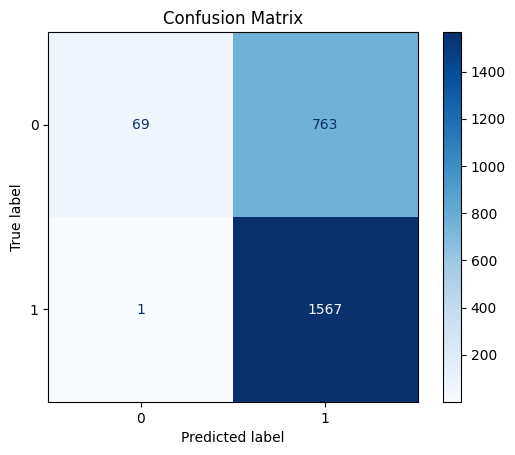

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [86]:
# Train Word2Vec on tokenized documents and build average vectors
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec
import numpy as np

# Tokenize all documents for training the embedding
all_docs = [simple_preprocess(text) for text in df['reviewText'].astype(str)]
# Train Word2Vec (small vector_size to keep memory small)
w2v_model = Word2Vec(sentences=all_docs, vector_size=100, window=5, min_count=2, workers=4, epochs=10)

def avg_word2vec(doc_tokens, model=w2v_model):
    # robust vocab check for gensim versions
    vocab = getattr(model.wv, 'key_to_index', None) or getattr(model.wv, 'index_to_key', None)
    vecs = [model.wv[word] for word in doc_tokens if vocab is not None and word in vocab]
    if len(vecs) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vecs, axis=0)

# Build vectors for train and test sets (use tokenized versions)
X_train_tokens = [simple_preprocess(x) for x in X_train.astype(str)]
X_test_tokens = [simple_preprocess(x) for x in X_test.astype(str)]
X_train_vecs = np.vstack([avg_word2vec(t) for t in X_train_tokens])
X_test_vecs = np.vstack([avg_word2vec(t) for t in X_test_tokens])

print('X_train_vecs shape:', X_train_vecs.shape)
print('X_test_vecs shape:', X_test_vecs.shape)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


X_train_vecs shape: (9600, 100)
X_test_vecs shape: (2400, 100)


              precision    recall  f1-score   support

           0       0.76      0.65      0.70       832
           1       0.83      0.89      0.86      1568

    accuracy                           0.81      2400
   macro avg       0.80      0.77      0.78      2400
weighted avg       0.81      0.81      0.80      2400

Accuracy: 0.80875


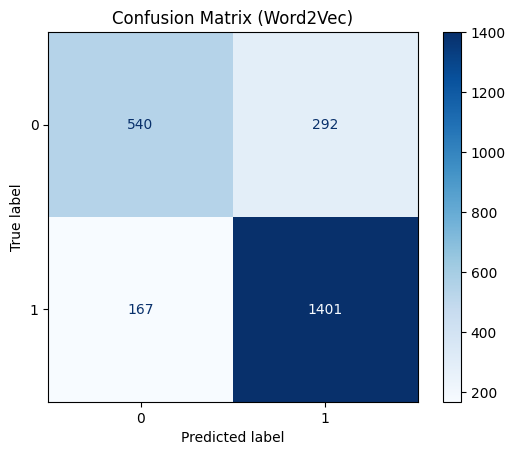

In [87]:
# Train a simple classifier on the Word2Vec document vectors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vecs, y_train)
y_pred = clf.predict(X_test_vecs)
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Word2Vec)')
plt.show()
